## 1. Environment Setup and Project Paths

In [76]:
# Cell 1: Setup and imports

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Project folders inside Colab
project_root= Path("/content/project_nuw")

data_dir = project_root / "data"
raw_dir = data_dir / "raw"
proxy_dir = data_dir / "proxy"
cleaned_dir = data_dir / "cleaned"
output_dir = project_root / "outputs"
final_dir = output_dir / "final"

for folder in [RAW_DIR, PROXY_DIR, CLEANED_DIR, FINAL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TARGET_DATE = "2026-06-20"

print("Setup complete")
print("Project root:", PROJECT_ROOT)
print("Target date:", TARGET_DATE)

Setup complete
Project root: /content/project_nuw
Target date: 2026-06-20


## 2. Connecting to Google Drive Input Files

In [77]:
# Cell 2: Set file paths from mounted Google Drive

from pathlib import Path

DRIVE_FOLDER = Path("/content/drive/MyDrive/Colab Notebooks")

TARGET_DATE = "2026-06-20"

LOAD_PATH = DRIVE_FOLDER / f"proxy_factory_load_{TARGET_DATE}.csv"
price_path_2026_06_20 = DRIVE_FOLDER / f"elexon_market_index_{TARGET_DATE}.csv"
price_path_2026_06_19 = DRIVE_FOLDER / "elexon_market_index_2026-06-19.csv"

print("Checking input files:")
print("Load file exists:", LOAD_PATH.exists(), LOAD_PATH)
print("20 June price file exists:", price_path_2026_06_20.exists(), price_path_2026_06_20)
print("19 June price file exists:", price_path_2026_06_19.exists(), price_path_2026_06_19)

Checking input files:
Load file exists: True /content/drive/MyDrive/Colab Notebooks/proxy_factory_load_2026-06-20.csv
20 June price file exists: True /content/drive/MyDrive/Colab Notebooks/elexon_market_index_2026-06-20.csv
19 June price file exists: True /content/drive/MyDrive/Colab Notebooks/elexon_market_index_2026-06-19.csv


## 3. Loading Factory Demand and Market Price Data

In [78]:
# Cell 3: Load input CSV files

load_df = pd.read_csv(LOAD_PATH)
price_20_df = pd.read_csv(price_path_2026_06_20)
price_19_df = pd.read_csv(price_path_2026_06_19)

print("Files loaded successfully")
print()

print("Load data shape:", load_df.shape)
print("20 June price data shape:", price_20_df.shape)
print("19 June price data shape:", price_19_df.shape)

print("\nLoad data preview:")
display(load_df.head())

print("\n20 June price data preview:")
display(price_20_df.head())

print("\n19 June price data preview:")
display(price_19_df.head())

Files loaded successfully

Load data shape: (48, 7)
20 June price data shape: (48, 8)
19 June price data shape: (48, 8)

Load data preview:


,date,settlement_period,start_time,end_time,proxy_kwh,load_band,assumption_note
0,2026-06-20,1,00:00,00:30,900,overnight_baseload,Proxy only - continuous manufacturing baseload
1,2026-06-20,2,00:30,01:00,900,overnight_baseload,Proxy only - continuous manufacturing baseload
2,2026-06-20,3,01:00,01:30,900,overnight_baseload,Proxy only - continuous manufacturing baseload
3,2026-06-20,4,01:30,02:00,900,overnight_baseload,Proxy only - continuous manufacturing baseload
4,2026-06-20,5,02:00,02:30,900,overnight_baseload,Proxy only - continuous manufacturing baseload



20 June price data preview:


,date,settlement_period,start_time_utc,data_provider,price_gbp_per_mwh,price_p_per_kwh,volume,source
0,2026-06-20,1,2026-06-19T23:00:00Z,APXMIDP,98.19,9.819,2284.35,Elexon BMRS market-index APXMIDP
1,2026-06-20,2,2026-06-19T23:30:00Z,APXMIDP,92.29,9.229,2239.10,Elexon BMRS market-index APXMIDP
2,2026-06-20,3,2026-06-20T00:00:00Z,APXMIDP,94.57,9.457,2656.85,Elexon BMRS market-index APXMIDP
3,2026-06-20,4,2026-06-20T00:30:00Z,APXMIDP,93.63,9.363,2454.30,Elexon BMRS market-index APXMIDP
4,2026-06-20,5,2026-06-20T01:00:00Z,APXMIDP,92.27,9.227,2768.80,Elexon BMRS market-index APXMIDP



19 June price data preview:


,date,settlement_period,start_time_utc,data_provider,price_gbp_per_mwh,price_p_per_kwh,volume,source
0,2026-06-19,1,2026-06-18T23:00:00Z,APXMIDP,98.72,9.872,1873.10,Elexon BMRS market-index APXMIDP
1,2026-06-19,2,2026-06-18T23:30:00Z,APXMIDP,94.34,9.434,1811.05,Elexon BMRS market-index APXMIDP
2,2026-06-19,3,2026-06-19T00:00:00Z,APXMIDP,85.86,8.586,1660.40,Elexon BMRS market-index APXMIDP
3,2026-06-19,4,2026-06-19T00:30:00Z,APXMIDP,84.71,8.471,1854.60,Elexon BMRS market-index APXMIDP
4,2026-06-19,5,2026-06-19T01:00:00Z,APXMIDP,88.42,8.842,2471.80,Elexon BMRS market-index APXMIDP


## 4. Data Quality Checks Before Modelling

In [79]:
# Cell 4: Inspect data structure and quality

print("Load data columns:")
print(load_df.columns.tolist())

print("\n20 June price data columns:")
print(price_20_df.columns.tolist())

print("\n19 June price data columns:")
print(price_19_df.columns.tolist())

print("\nMissing values in load data:")
display(load_df.isna().sum())

print("\nMissing values in 20 June price data:")
display(price_20_df.isna().sum())

print("\nMissing values in 19 June price data:")
display(price_19_df.isna().sum())

print("\nSettlement period coverage:")

for name, df in [
    ("Load data", load_df),
    ("20 June price data", price_20_df),
    ("19 June price data", price_19_df),
]:
    if "settlement_period" in df.columns:
        period_col = "settlement_period"
    elif "settlementPeriod" in df.columns:
        period_col = "settlementPeriod"
    else:
        print(f"{name}: no settlement period column found")
        continue

    periods = sorted(df[period_col].dropna().astype(int).unique().tolist())
    missing = [p for p in range(1, 49) if p not in periods]

    print(f"{name}: {len(periods)} unique periods")
    print(f"Missing periods: {missing}")

Load data columns:
['date', 'settlement_period', 'start_time', 'end_time', 'proxy_kwh', 'load_band', 'assumption_note']

20 June price data columns:
['date', 'settlement_period', 'start_time_utc', 'data_provider', 'price_gbp_per_mwh', 'price_p_per_kwh', 'volume', 'source']

19 June price data columns:
['date', 'settlement_period', 'start_time_utc', 'data_provider', 'price_gbp_per_mwh', 'price_p_per_kwh', 'volume', 'source']

Missing values in load data:


,0
date,0
settlement_period,0
start_time,0
end_time,0
proxy_kwh,0
load_band,0
assumption_note,0



Missing values in 20 June price data:


,0
date,0
settlement_period,0
start_time_utc,0
data_provider,0
price_gbp_per_mwh,0
price_p_per_kwh,0
volume,0
source,0



Missing values in 19 June price data:


,0
date,0
settlement_period,0
start_time_utc,0
data_provider,0
price_gbp_per_mwh,0
price_p_per_kwh,0
volume,0
source,0



Settlement period coverage:
Load data: 48 unique periods
Missing periods: []
20 June price data: 48 unique periods
Missing periods: []
19 June price data: 48 unique periods
Missing periods: []


## 5. Standardising Settlement Period and Price Fields

In [80]:
# Cell 5: Clean and standardize load and price data

# Copy raw data so original dataframes stay unchanged
load_clean = load_df.copy()
price_clean = price_20_df.copy()

# Standardize settlement period column name if needed
if "settlementPeriod" in load_clean.columns and "settlement_period" not in load_clean.columns:
    load_clean = load_clean.rename(columns={"settlementPeriod": "settlement_period"})

if "settlementPeriod" in price_clean.columns and "settlement_period" not in price_clean.columns:
    price_clean = price_clean.rename(columns={"settlementPeriod": "settlement_period"})

# Standardize price column name
if "price" in price_clean.columns and "price_gbp_per_mwh" not in price_clean.columns:
    price_clean = price_clean.rename(columns={"price": "price_gbp_per_mwh"})

# Keep only APXMIDP provider if the column exists
if "dataProvider" in price_clean.columns:
    price_clean = price_clean[price_clean["dataProvider"] == "APXMIDP"].copy()

# Convert types
load_clean["settlement_period"] = load_clean["settlement_period"].astype(int)
price_clean["settlement_period"] = price_clean["settlement_period"].astype(int)

load_clean["proxy_kwh"] = pd.to_numeric(load_clean["proxy_kwh"], errors="coerce")
price_clean["price_gbp_per_mwh"] = pd.to_numeric(price_clean["price_gbp_per_mwh"], errors="coerce")

# Convert GBP/MWh to p/kWh
price_clean["price_p_per_kwh"] = price_clean["price_gbp_per_mwh"] / 10

# Sort by settlement period
load_clean = load_clean.sort_values("settlement_period").reset_index(drop=True)
price_clean = price_clean.sort_values("settlement_period").reset_index(drop=True)

print("Cleaned load shape:", load_clean.shape)
print("Cleaned price shape:", price_clean.shape)

print("\nCleaned load preview:")
display(load_clean.head())

print("\nCleaned price preview:")
display(price_clean.head())

Cleaned load shape: (48, 7)
Cleaned price shape: (48, 8)

Cleaned load preview:


,date,settlement_period,start_time,end_time,proxy_kwh,load_band,assumption_note
0,2026-06-20,1,00:00,00:30,900,overnight_baseload,Proxy only - continuous manufacturing baseload
1,2026-06-20,2,00:30,01:00,900,overnight_baseload,Proxy only - continuous manufacturing baseload
2,2026-06-20,3,01:00,01:30,900,overnight_baseload,Proxy only - continuous manufacturing baseload
3,2026-06-20,4,01:30,02:00,900,overnight_baseload,Proxy only - continuous manufacturing baseload
4,2026-06-20,5,02:00,02:30,900,overnight_baseload,Proxy only - continuous manufacturing baseload



Cleaned price preview:


,date,settlement_period,start_time_utc,data_provider,price_gbp_per_mwh,price_p_per_kwh,volume,source
0,2026-06-20,1,2026-06-19T23:00:00Z,APXMIDP,98.19,9.819,2284.35,Elexon BMRS market-index APXMIDP
1,2026-06-20,2,2026-06-19T23:30:00Z,APXMIDP,92.29,9.229,2239.10,Elexon BMRS market-index APXMIDP
2,2026-06-20,3,2026-06-20T00:00:00Z,APXMIDP,94.57,9.457,2656.85,Elexon BMRS market-index APXMIDP
3,2026-06-20,4,2026-06-20T00:30:00Z,APXMIDP,93.63,9.363,2454.30,Elexon BMRS market-index APXMIDP
4,2026-06-20,5,2026-06-20T01:00:00Z,APXMIDP,92.27,9.227,2768.80,Elexon BMRS market-index APXMIDP


## 6. Validating Complete Half-Hourly Coverage

In [81]:
# Cell 6: Validate cleaned datasets

def validate_48_periods(df, period_col, label):
    periods = df[period_col].dropna().astype(int).tolist()
    unique_periods = sorted(set(periods))

    missing = [p for p in range(1, 49) if p not in unique_periods]
    duplicates = sorted([p for p in unique_periods if periods.count(p) > 1])

    print(f"{label}")
    print("Rows:", len(df))
    print("Unique settlement periods:", len(unique_periods))
    print("Missing periods:", missing)
    print("Duplicate periods:", duplicates)
    print()

    if missing:
        raise ValueError(f"{label} has missing settlement periods: {missing}")

    if duplicates:
        raise ValueError(f"{label} has duplicate settlement periods: {duplicates}")

    if len(df) != 48:
        raise ValueError(f"{label} should have exactly 48 rows, but has {len(df)}")

validate_48_periods(load_clean, "settlement_period", "Load data")
validate_48_periods(price_clean, "settlement_period", "Price data")

if load_clean["proxy_kwh"].isna().any():
    raise ValueError("Load data has missing or invalid proxy_kwh values")

if price_clean["price_gbp_per_mwh"].isna().any():
    raise ValueError("Price data has missing or invalid price values")

if (load_clean["proxy_kwh"] < 0).any():
    raise ValueError("Load data contains negative proxy_kwh values")

print("Validation passed")

Load data
Rows: 48
Unique settlement periods: 48
Missing periods: []
Duplicate periods: []

Price data
Rows: 48
Unique settlement periods: 48
Missing periods: []
Duplicate periods: []

Validation passed


## 7. Building the Load-Weighted Exposure Model

In [82]:
# Cell 7: Merge load and price data, then calculate exposure

model_df = load_clean.merge(
    price_clean[
        [
            "settlement_period",
            "price_gbp_per_mwh",
            "price_p_per_kwh"
        ]
    ],
    on="settlement_period",
    how="inner"
)

model_df["weighted_exposure_pence"] = (
    model_df["proxy_kwh"] * model_df["price_p_per_kwh"]
)

model_df["weighted_exposure_gbp"] = model_df["weighted_exposure_pence"] / 100

print("Model dataframe shape:", model_df.shape)

display(
    model_df[
        [
            "date",
            "settlement_period",
            "start_time",
            "end_time",
            "proxy_kwh",
            "price_gbp_per_mwh",
            "price_p_per_kwh",
            "weighted_exposure_pence",
            "weighted_exposure_gbp"
        ]
    ].head()
)

Model dataframe shape: (48, 11)


,date,settlement_period,start_time,end_time,proxy_kwh,price_gbp_per_mwh,price_p_per_kwh,weighted_exposure_pence,weighted_exposure_gbp
0,2026-06-20,1,00:00,00:30,900,98.19,9.819,8837.1,88.371
1,2026-06-20,2,00:30,01:00,900,92.29,9.229,8306.1,83.061
2,2026-06-20,3,01:00,01:30,900,94.57,9.457,8511.3,85.113
3,2026-06-20,4,01:30,02:00,900,93.63,9.363,8426.7,84.267
4,2026-06-20,5,02:00,02:30,900,92.27,9.227,8304.3,83.043


## 8. Final Exposure Estimate

In [83]:
# Cell 8: Calculate final exposure summary metrics

total_proxy_kwh = model_df["proxy_kwh"].sum()
total_weighted_exposure_pence = model_df["weighted_exposure_pence"].sum()
total_weighted_exposure_gbp = model_df["weighted_exposure_gbp"].sum()

simple_average_price_p_per_kwh = model_df["price_p_per_kwh"].mean()
load_weighted_exposure_p_per_kwh = total_weighted_exposure_pence / total_proxy_kwh

minimum_price_p_per_kwh = model_df["price_p_per_kwh"].min()
maximum_price_p_per_kwh = model_df["price_p_per_kwh"].max()

summary_df = pd.DataFrame([
    {
        "run_timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "target_date": TARGET_DATE,
        "settlement_period_count": len(model_df),
        "total_proxy_kwh": round(total_proxy_kwh, 3),
        "total_weighted_exposure_gbp": round(total_weighted_exposure_gbp, 4),
        "simple_average_price_p_per_kwh": round(simple_average_price_p_per_kwh, 4),
        "load_weighted_exposure_p_per_kwh": round(load_weighted_exposure_p_per_kwh, 4),
        "minimum_price_p_per_kwh": round(minimum_price_p_per_kwh, 4),
        "maximum_price_p_per_kwh": round(maximum_price_p_per_kwh, 4),
        "status_note": "Actual Elexon APXMIDP price run"
    }
])

display(summary_df)

,run_timestamp_utc,target_date,settlement_period_count,total_proxy_kwh,total_weighted_exposure_gbp,simple_average_price_p_per_kwh,load_weighted_exposure_p_per_kwh,minimum_price_p_per_kwh,maximum_price_p_per_kwh,status_note
0,2026-06-22T10:32:09+00:00,2026-06-20,48,73400,7993.996,10.9787,10.891,9.227,14.873,Actual Elexon APXMIDP price run


## 9. Simple Average Price vs Load-Weighted Price

In [84]:
# Cell 9: Compare simple average price vs load-weighted exposure

comparison_df = pd.DataFrame([
    {
        "metric": "Simple average market price",
        "value_p_per_kwh": simple_average_price_p_per_kwh
    },
    {
        "metric": "Load-weighted exposure",
        "value_p_per_kwh": load_weighted_exposure_p_per_kwh
    }
])

comparison_df["value_p_per_kwh"] = comparison_df["value_p_per_kwh"].round(4)

difference_p_per_kwh = load_weighted_exposure_p_per_kwh - simple_average_price_p_per_kwh
difference_percent = (difference_p_per_kwh / simple_average_price_p_per_kwh) * 100

display(comparison_df)

print("Difference, p/kWh:", round(difference_p_per_kwh, 4))
print("Difference, %:", round(difference_percent, 2))

,metric,value_p_per_kwh
0,Simple average market price,10.9787
1,Load-weighted exposure,10.8910


Difference, p/kWh: -0.0877
Difference, %: -0.8


## 10. Interpreting the Exposure Difference

In [85]:
# Cell 10: Add interpretation fields to summary

summary_df["simple_vs_weighted_difference_p_per_kwh"] = round(difference_p_per_kwh, 4)
summary_df["simple_vs_weighted_difference_percent"] = round(difference_percent, 2)

if difference_p_per_kwh < 0:
    interpretation = "Load-weighted exposure is lower than the simple average price, indicating higher consumption during relatively cheaper periods."
elif difference_p_per_kwh > 0:
    interpretation = "Load-weighted exposure is higher than the simple average price, indicating higher consumption during relatively expensive periods."
else:
    interpretation = "Load-weighted exposure equals the simple average price."

summary_df["interpretation"] = interpretation

display(summary_df)

,run_timestamp_utc,target_date,settlement_period_count,total_proxy_kwh,total_weighted_exposure_gbp,simple_average_price_p_per_kwh,load_weighted_exposure_p_per_kwh,minimum_price_p_per_kwh,maximum_price_p_per_kwh,status_note,simple_vs_weighted_difference_p_per_kwh,simple_vs_weighted_difference_percent,interpretation
0,2026-06-22T10:32:09+00:00,2026-06-20,48,73400,7993.996,10.9787,10.891,9.227,14.873,Actual Elexon APXMIDP price run,-0.0877,-0.8,Load-weighted exposure is lower than the simpl...


## 11. Cheapest, Costliest, and Highest-Exposure Periods

In [86]:
# Cell 11: Identify cheapest, most expensive, and highest exposure periods

cheapest_periods = model_df.sort_values("price_p_per_kwh").head(5)
most_expensive_periods = model_df.sort_values("price_p_per_kwh", ascending=False).head(5)
highest_exposure_periods = model_df.sort_values("weighted_exposure_gbp", ascending=False).head(5)

print("5 cheapest settlement periods:")
display(
    cheapest_periods[
        [
            "settlement_period",
            "start_time",
            "end_time",
            "proxy_kwh",
            "price_p_per_kwh",
            "weighted_exposure_gbp"
        ]
    ]
)

print("5 most expensive settlement periods:")
display(
    most_expensive_periods[
        [
            "settlement_period",
            "start_time",
            "end_time",
            "proxy_kwh",
            "price_p_per_kwh",
            "weighted_exposure_gbp"
        ]
    ]
)

print("5 highest exposure settlement periods:")
display(
    highest_exposure_periods[
        [
            "settlement_period",
            "start_time",
            "end_time",
            "proxy_kwh",
            "price_p_per_kwh",
            "weighted_exposure_gbp"
        ]
    ]
)

5 cheapest settlement periods:


,settlement_period,start_time,end_time,proxy_kwh,price_p_per_kwh,weighted_exposure_gbp
4,5,02:00,02:30,900,9.227,83.043
1,2,00:30,01:00,900,9.229,83.061
3,4,01:30,02:00,900,9.363,84.267
5,6,02:30,03:00,900,9.370,84.330
2,3,01:00,01:30,900,9.457,85.113


5 most expensive settlement periods:


,settlement_period,start_time,end_time,proxy_kwh,price_p_per_kwh,weighted_exposure_gbp
42,43,21:00,21:30,1000,14.873,148.730
43,44,21:30,22:00,1000,14.782,147.820
41,42,20:30,21:00,1200,14.394,172.728
40,41,20:00,20:30,1200,13.975,167.700
38,39,19:00,19:30,1200,13.752,165.024


5 highest exposure settlement periods:


,settlement_period,start_time,end_time,proxy_kwh,price_p_per_kwh,weighted_exposure_gbp
18,19,09:00,09:30,2200,12.203,268.466
19,20,09:30,10:00,2200,12.152,267.344
20,21,10:00,10:30,2200,11.998,263.956
17,18,08:30,09:00,2200,11.481,252.582
21,22,10:30,11:00,2200,11.432,251.504


## 12. Segmenting the Day into Price Exposure Bands

In [87]:
# Cell 12: Classify each settlement period into exposure bands

def classify_exposure(row):
    if row["price_p_per_kwh"] >= model_df["price_p_per_kwh"].quantile(0.75):
        return "High price period"
    elif row["price_p_per_kwh"] <= model_df["price_p_per_kwh"].quantile(0.25):
        return "Low price period"
    else:
        return "Medium price period"

model_df["price_exposure_band"] = model_df.apply(classify_exposure, axis=1)

band_summary_df = (
    model_df
    .groupby("price_exposure_band")
    .agg(
        settlement_period_count=("settlement_period", "count"),
        total_proxy_kwh=("proxy_kwh", "sum"),
        average_price_p_per_kwh=("price_p_per_kwh", "mean"),
        total_weighted_exposure_gbp=("weighted_exposure_gbp", "sum")
    )
    .reset_index()
)

band_summary_df["total_proxy_kwh"] = band_summary_df["total_proxy_kwh"].round(3)
band_summary_df["average_price_p_per_kwh"] = band_summary_df["average_price_p_per_kwh"].round(4)
band_summary_df["total_weighted_exposure_gbp"] = band_summary_df["total_weighted_exposure_gbp"].round(4)

display(band_summary_df)

,price_exposure_band,settlement_period_count,total_proxy_kwh,average_price_p_per_kwh,total_weighted_exposure_gbp
0,High price period,12,16300,13.3870,2142.343
1,Low price period,12,16900,9.5478,1623.097
2,Medium price period,24,40200,10.4900,4228.556


## 13. Load Share and Exposure Share by Price Band

In [88]:
# Cell 13: Calculate load and exposure shares by price band

band_summary_df["load_share_percent"] = (
    band_summary_df["total_proxy_kwh"] / band_summary_df["total_proxy_kwh"].sum() * 100
).round(2)

band_summary_df["exposure_share_percent"] = (
    band_summary_df["total_weighted_exposure_gbp"] / band_summary_df["total_weighted_exposure_gbp"].sum() * 100
).round(2)

band_summary_df = band_summary_df.sort_values(
    "price_exposure_band",
    key=lambda s: s.map({
        "Low price period": 1,
        "Medium price period": 2,
        "High price period": 3
    })
).reset_index(drop=True)

display(band_summary_df)

,price_exposure_band,settlement_period_count,total_proxy_kwh,average_price_p_per_kwh,total_weighted_exposure_gbp,load_share_percent,exposure_share_percent
0,Low price period,12,16900,9.5478,1623.097,23.02,20.3
1,Medium price period,24,40200,10.4900,4228.556,54.77,52.9
2,High price period,12,16300,13.3870,2142.343,22.21,26.8


## 14. Factory Load vs Market Price Over the Day

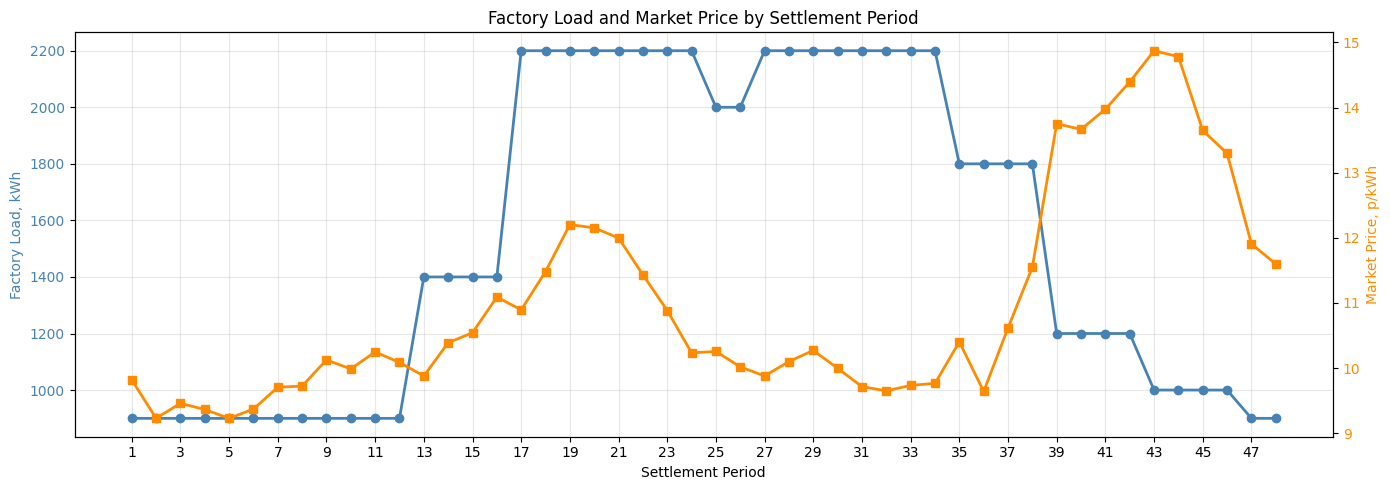

In [89]:
# Cell 14: Dual-axis chart of factory load and market price

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    model_df["settlement_period"],
    model_df["proxy_kwh"],
    marker="o",
    linewidth=2,
    color="steelblue",
    label="Factory load, kWh"
)

ax1.set_xlabel("Settlement Period")
ax1.set_ylabel("Factory Load, kWh", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(1, 49, 2))
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    model_df["settlement_period"],
    model_df["price_p_per_kwh"],
    marker="s",
    linewidth=2,
    color="darkorange",
    label="Market price, p/kWh"
)

ax2.set_ylabel("Market Price, p/kWh", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Factory Load and Market Price by Settlement Period")

fig.tight_layout()
plt.show()

## 15. Half-Hourly Weighted Exposure Profile

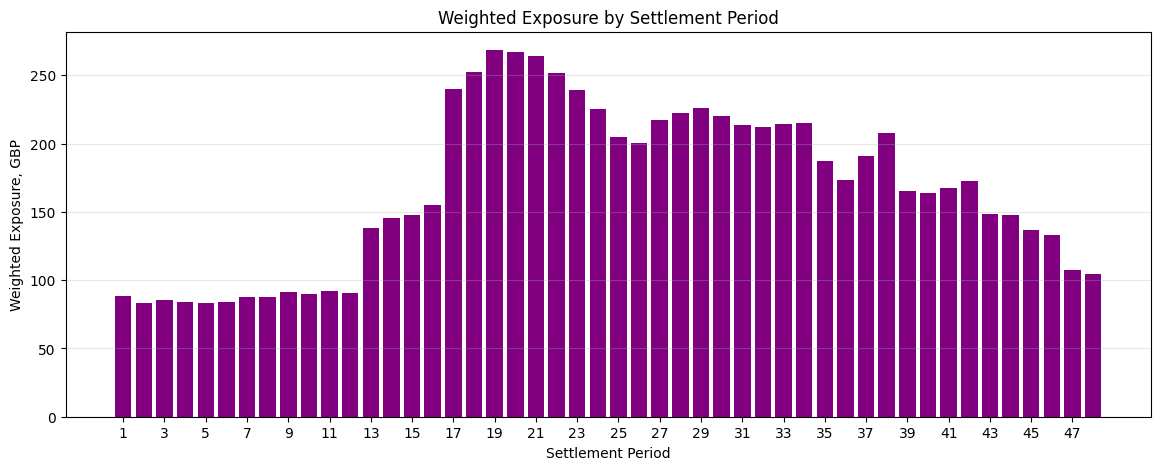

In [90]:
# Cell 15: Weighted exposure by settlement period

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.bar(
    model_df["settlement_period"],
    model_df["weighted_exposure_gbp"],
    color="purple"
)

plt.title("Weighted Exposure by Settlement Period")
plt.xlabel("Settlement Period")
plt.ylabel("Weighted Exposure, GBP")
plt.xticks(range(1, 49, 2))
plt.grid(axis="y", alpha=0.3)

plt.show()

## 16. Price Band Contribution Analysis

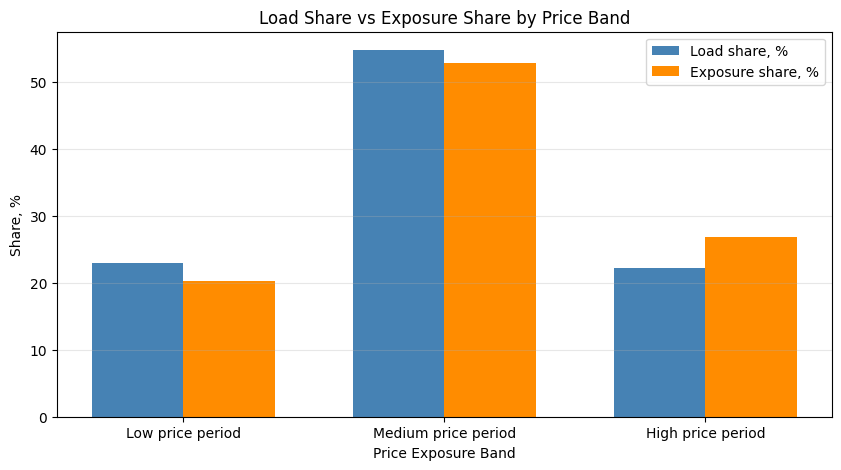

In [91]:
# Cell 16: Price band share chart

import matplotlib.pyplot as plt
import numpy as np

band_plot_df = band_summary_df.copy()

x = np.arange(len(band_plot_df))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    band_plot_df["load_share_percent"],
    width,
    label="Load share, %",
    color="steelblue"
)

plt.bar(
    x + width / 2,
    band_plot_df["exposure_share_percent"],
    width,
    label="Exposure share, %",
    color="darkorange"
)

plt.title("Load Share vs Exposure Share by Price Band")
plt.xlabel("Price Exposure Band")
plt.ylabel("Share, %")
plt.xticks(x, band_plot_df["price_exposure_band"])
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## 17. Market Price and Factory Load Relationship

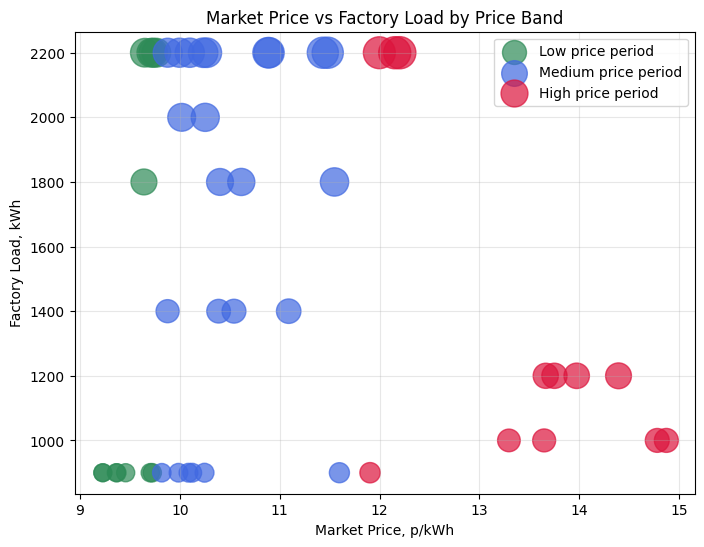

In [92]:
# Cell 17: Scatter plot of market price vs factory load by price band

import matplotlib.pyplot as plt

band_colors = {
    "Low price period": "seagreen",
    "Medium price period": "royalblue",
    "High price period": "crimson"
}

plt.figure(figsize=(8, 6))

for band, color in band_colors.items():
    band_data = model_df[model_df["price_exposure_band"] == band]

    plt.scatter(
        band_data["price_p_per_kwh"],
        band_data["proxy_kwh"],
        s=band_data["weighted_exposure_gbp"] * 2,
        alpha=0.7,
        color=color,
        label=band
    )

plt.title("Market Price vs Factory Load by Price Band")
plt.xlabel("Market Price, p/kWh")
plt.ylabel("Factory Load, kWh")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 18. Exporting Final Model Outputs

In [93]:
# Cell 18: Save final model outputs to Google Drive

OUTPUT_FOLDER = Path("/content/drive/MyDrive/Colab Notebooks/project_nuw_outputs")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

model_output_path = OUTPUT_FOLDER / f"weighted_exposure_{TARGET_DATE}.csv"
summary_output_path = OUTPUT_FOLDER / f"exposure_summary_{TARGET_DATE}.csv"
band_summary_output_path = OUTPUT_FOLDER / f"exposure_band_summary_{TARGET_DATE}.csv"

model_df.to_csv(model_output_path, index=False)
summary_df.to_csv(summary_output_path, index=False)
band_summary_df.to_csv(band_summary_output_path, index=False)

print("Saved model output:", model_output_path)
print("Saved summary output:", summary_output_path)
print("Saved band summary output:", band_summary_output_path)

Saved model output: /content/drive/MyDrive/Colab Notebooks/project_nuw_outputs/weighted_exposure_2026-06-20.csv
Saved summary output: /content/drive/MyDrive/Colab Notebooks/project_nuw_outputs/exposure_summary_2026-06-20.csv
Saved band summary output: /content/drive/MyDrive/Colab Notebooks/project_nuw_outputs/exposure_band_summary_2026-06-20.csv
